In [5]:
# ==========================================================
# Celda 01 — Importación de paquetes
# ==========================================================
import sys
import os
from datetime import datetime

import numpy as np

import matplotlib
matplotlib.rcParams['text.usetex'] = True
import matplotlib.pyplot as plt

from scipy.linalg import sqrtm
from scipy.linalg import inv

from joblib import Parallel, delayed

sys.path.insert(0, '../')
from codes.Quantum import *
from codes.CSPSA import *


In [6]:
# ==========================================================
# Celda 02 — Definición de funciones base
# ==========================================================

def complex2unitary( Z ):
    if Z.ndim == 3:
        for k, z in enumerate(Z):
            Z[k] = z @ inv( sqrtm( z.T.conj()@z ) )
    else:
        Z = Z @ inv( sqrtm( Z.T.conj()@Z ) )
    return Z 

def random_unitary( dim, num=1 ):
    Z = np.random.randn( num, dim, dim ) \
        + 1j*np.random.randn( num, dim, dim )
    return complex2unitary( Z ).squeeze()

def postprocessing(U):
    return complex2unitary( U )

def trineq(Us, Psi ):

    Us = np.array(Us)
    Us = complex2unitary( Us )

    probs = np.abs( LocalProduct( Psi, Us ).reshape(6*[2]) )**2

    probs_albl = np.sum( probs, axis=(1,3,4,5) )
    probs_alblclcr = np.sum( probs, axis=(1,3) )
    probs_clcr = np.sum( probs, axis=(0,1,2,3) )

    inequality = (-probs_albl[1,0] 
                +probs_alblclcr[1,0,1,0] 
                -probs_albl[0,1] * probs_clcr[1,0] 
                -probs_clcr[0,0] * probs_clcr[1,1] 
                -probs_clcr[0,1] * probs[1,0,0,1,1,0]
                -probs_clcr[0,1] * probs[1,1,0,0,1,0]
                +probs_clcr[0,0] * probs[1,0,1,1,1,1]
                +probs_clcr[0,0] * probs[1,1,1,0,1,1]
                +probs_clcr[1,0] * probs[0,0,1,0,0,1]
                +probs_clcr[1,0] * probs[0,1,1,1,0,1]
                +probs_clcr[1,1] * probs[0,0,0,0,0,0]
                +probs_clcr[1,1] * probs[0,1,0,1,0,0]
                )
    return inequality


def construir_psi_max_ent():
    """
    Construye el estado de la red triangular donde las tres fuentes son
    estados de Bell maximalmente entrelazados:
        |Psi_ab> = (|01> - |10>) / sqrt(2)
    aplicado simétricamente a las tres fuentes (alpha, beta, gamma).
    """
    Psi_ab = np.array([ 0, 1, -1, 0 ]) / np.sqrt(2)
    Psi = triple_kron( Psi_ab, Psi_ab, Psi_ab )
    Psi = Psi.reshape(6*[2]).transpose([5,0,2,1,4,3]).flatten()
    return Psi


In [7]:
# ==========================================================
# Celda 03 — Mediciones óptimas y validación del funcional trineq
# ==========================================================
M = np.zeros( (2,2,2,2) )

M[0,1,:,:] = np.array([  [1, 0], [0, 1]  ]) #Z
M[0,0,:,:] = np.array([  [1, 1], [1, -1]  ])/np.sqrt(2) #X

M[1,0,0,:] = np.array([1-np.sqrt(2), 1])/np.sqrt( 2*(2-np.sqrt(2)) )  #X+Z
M[1,0,1,:] = np.array([1+np.sqrt(2), 1])/np.sqrt( 2*(2+np.sqrt(2)) )

M[1,1,0,:] = np.array([-1-np.sqrt(2), 1])/np.sqrt( 2*(2+np.sqrt(2)) )
M[1,1,1,:] = np.array([-1+np.sqrt(2), 1])/np.sqrt( 2*(2-np.sqrt(2)) ) #

Comp_basis = np.eye(2) 

vec_alice = np.zeros( (2,2,4) )
for l in range(2):
    for k in range(2):
        vec_alice[l,k,:]  = np.kron( Comp_basis[l], M[0,l,k,:] )
vec_alice = vec_alice.reshape(4,4)

vec_bob = np.zeros( (2,2,4) )
for m in range(2):
    for kk in range(2):
        vec_bob[m,kk,:] = np.kron( Comp_basis[m], M[1,m,kk,:] )
vec_bob = vec_bob.reshape(4,4)

Comp_basis = np.array([ 0,1,1,0 ]).reshape(2,2)
vec_charlie = np.zeros( (2,2,4) )
for i in range(2):
    for j in range(2):
        vec_charlie[i,j,:] = np.kron( Comp_basis[i], Comp_basis[j] )
vec_charlie = vec_charlie.reshape(4,4)

Psi_validacion = construir_psi_max_ent()

trineq( np.array([vec_alice, vec_bob, vec_charlie]), Psi_validacion ), (np.sqrt(2)-1)/16 


(np.float64(0.02588834764831843), np.float64(0.025888347648318447))

In [8]:
# ==========================================================
# Celda 04 — Simulación: tres fuentes de Bell maximalmente entrelazadas
# ==========================================================

def _una_repeticion_maxent(gains, max_iter):
    """
    Una repetición de CSPSA sobre el estado fijo de tres fuentes de Bell
    maximalmente entrelazadas (sin parámetro variable).
    """
    Psi = construir_psi_max_ent()

    Us_in = np.array([ np.kron(random_unitary(2), random_unitary(2)) for _ in range(3) ])
    cspsa = CSPSA(gains=gains, minimize=False)

    results = cspsa.minimize(trineq, Us_in,
                                max_iter,
                                args = (Psi),
                                postprocessing=postprocessing )
    return results.fun


def ejecutar_simulacion_maxent(max_rep, max_iter, gains, sim_id, carpeta_sim,
                                fecha=None, n_jobs=-1):
    """
    Ejecuta CSPSA sobre el estado fijo (tres Bell maximalmente
    entrelazados), paralelizando las max_rep repeticiones. Guarda un
    único archivo .npz (no hay barrido de parámetro en esta simulación).
    Nombre de archivo: {sim_id}_{fecha}.npz
    """
    if fecha is None:
        fecha = datetime.now().strftime("%Y%m%d")

    os.makedirs(carpeta_sim, exist_ok=True)

    print(f"[{sim_id}] tres fuentes Bell max. entrelazadas "
          f"(paralelizando {max_rep} repeticiones, n_jobs={n_jobs})")

    resultados = Parallel(n_jobs=n_jobs)(
        delayed(_una_repeticion_maxent)(gains, max_iter) for _ in range(max_rep)
    )
    Out = np.array(resultados)

    nombre = f"{sim_id}_{fecha}.npz"
    ruta = os.path.join(carpeta_sim, nombre)

    np.savez(ruta,
             Out=Out,
             mean=Out.mean(axis=0),
             median=np.median(Out, axis=0),
             q1=np.percentile(Out, 25, axis=0),
             q3=np.percentile(Out, 75, axis=0),
             gains=gains, max_iter=max_iter,
             max_rep=max_rep, sim_id=sim_id, fecha=fecha)

    print(f"  Guardado: {ruta}")


# Simulación 01

**Carpeta de datos:** `Simulacion_01`

**Parámetros:**

| Parámetro | Valor |
|---|---|
| Estado | Tres fuentes de Bell maximalmente entrelazadas ($\alpha=\beta=\gamma=0.5$) |
| `max_rep` | 100 |
| `max_iter` | 1000 |
| `gains` | `[3, 0, 0.1, 0.602, 0.101]` |
| Optimizador | CSPSA (`minimize=False`, maximización) |

**Descripción:** a diferencia de las simulaciones de Schmidt y Werner, aquí
no hay parámetro variable: las tres fuentes de la red triangular están
fijas como estados de Bell maximalmente entrelazados
($|\Psi_{ab}\rangle=(|01\rangle-|10\rangle)/\sqrt{2}$). El objetivo es
tener una referencia de convergencia de CSPSA en el caso de máximo
entrelazamiento simétrico, comparable directamente contra el valor óptimo
de Fritz.

**Archivos generados:** `Simulacion_01/Sim01_{fecha}.npz`


In [ ]:
# ==========================================================
# Simulación 01 — Ejecución
# ==========================================================
max_rep_sim01 = 100
max_iter_sim01 = 1000
gains_sim01 = [3, 0, 0.1, 0.602, 0.101]
carpeta_sim01 = "Simulacion_01"
fecha_sim01 = datetime.now().strftime("%Y%m%d")

#ejecutar_simulacion_maxent(max_rep_sim01, max_iter_sim01,
#                            gains_sim01, "Sim01", carpeta_sim01, fecha_sim01)


[Sim01] tres fuentes Bell max. entrelazadas (paralelizando 100 repeticiones, n_jobs=-1)
  Guardado: Simulacion_01\Sim01_20260804.npz


# Gráficos

Esta sección se ejecuta **después** de correr la Simulación 01.


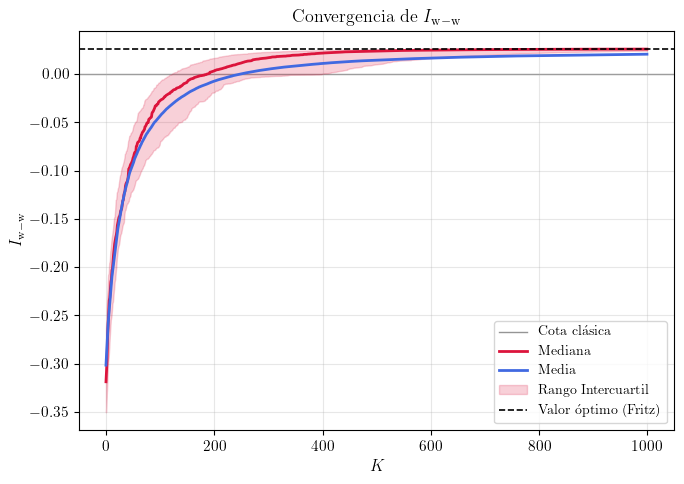

In [97]:
# ==========================================================
# Configuración de estilo — Mantener la uniformidad de los gráficos
# ==========================================================
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

# ==========================================================
# Gráfico — Convergencia (mediana, media, IQR) — tres Bell max. entrelazados
# ==========================================================
import glob

def cargar_ultimo_npz_maxent(carpeta, sim_id):
    patron = os.path.join(carpeta, f"{sim_id}_*.npz")
    archivos = sorted(glob.glob(patron))
    assert archivos, f"No se encontró ningún archivo para {sim_id} en {carpeta}"
    return np.load(archivos[-1])

valor_fritz = (np.sqrt(2) - 1) / 16
carpeta_sim01 = "Simulacion_01"

Data = cargar_ultimo_npz_maxent(carpeta_sim01, "Sim01")

mean = Data['mean']
median = Data['median']
q1 = Data['q1']
q3 = Data['q3']
it = np.arange(len(median))

plt.figure(figsize=(7,5))

plt.axhline(0, color='dimgray', linestyle='-', linewidth=1.0, alpha=0.7,
            label='Cota clásica', zorder=1)
plt.plot(it, median, color='crimson', label='Mediana', linewidth=2, zorder=3)
plt.plot(it, mean, color='royalblue', label='Media', linewidth=2, zorder=3)
plt.fill_between(it, q1, q3, color='crimson', alpha=0.2, label='Rango Intercuartil', zorder=2)
plt.axhline(valor_fritz, color='black', linestyle='--', linewidth=1.2,
            label=r'Valor óptimo (Fritz)', zorder=3)

plt.xlabel(r"$K$")
plt.ylabel(r"$I_{\rm w-w}$")
plt.title(r"Convergencia de $I_{\rm w-w}$")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("Simulacion_01/Sim01_Max_Ent.pdf")
plt.savefig("Simulacion_01/Sim01_Max_Ent.png", dpi=600)
plt.show()


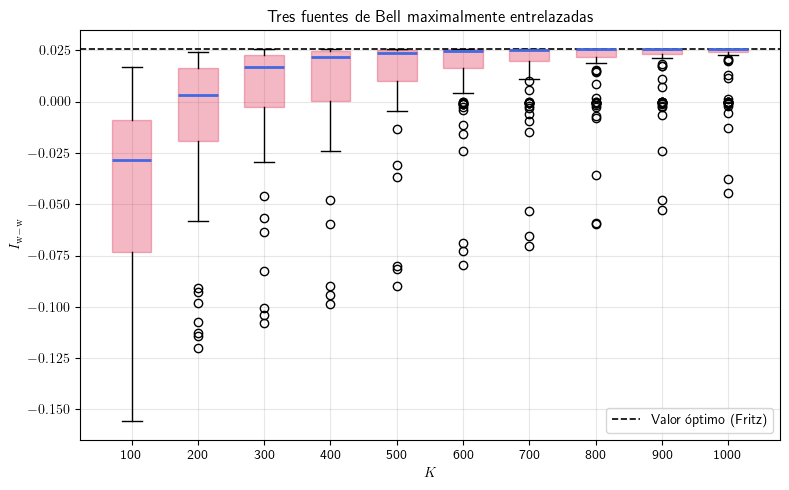

In [10]:
# ==========================================================
# Boxplot — dispersión cada 100 iteraciones (tres Bell max. entrelazados)
# ==========================================================
checkpoints_K = np.arange(100, 1001, 100)   # 100, 200, ..., 1000

Out = Data['Out']
datos_boxplot = [Out[:, k-1] for k in checkpoints_K]

plt.figure(figsize=(8,5))

box = plt.boxplot(datos_boxplot, positions=checkpoints_K, widths=60,
                   patch_artist=True, showfliers=True)

for caja in box['boxes']:
    caja.set(facecolor='crimson', alpha=0.3, edgecolor='crimson')
for mediana in box['medians']:
    mediana.set(color='royalblue', linewidth=2)

plt.axhline(valor_fritz, color='black', linestyle='--', linewidth=1.2,
            label=r'Valor óptimo (Fritz)')

plt.xlabel(r"$K$")
plt.ylabel(r"$I_{\rm w-w}$")
plt.title(r"Tres fuentes de Bell maximalmente entrelazadas")
plt.xticks(checkpoints_K)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


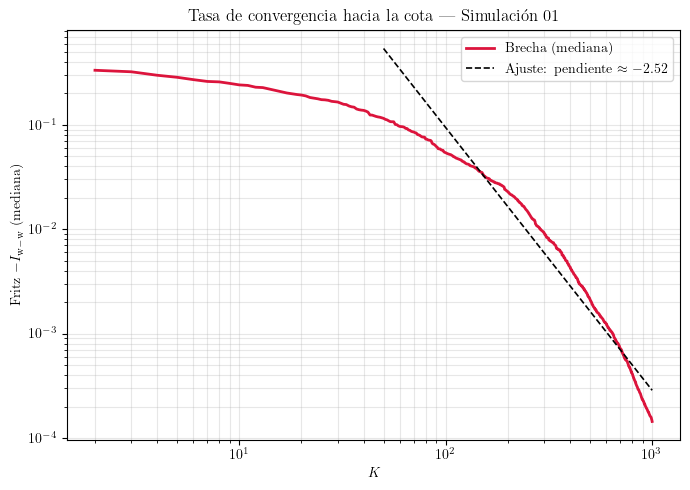

Tasa de convergencia estimada (pendiente en log-log): -2.516


In [93]:
import os
import numpy as np

carpeta_sim01 = "Simulacion_01"
ruta_sim01 = os.path.join(carpeta_sim01, "Sim01_20260804.npz")
Data_sim01 = np.load(ruta_sim01)

Out = Data_sim01['Out']            # (max_rep, max_iter)
median = Data_sim01['median']
valor_fritz = (np.sqrt(2) - 1) / 16

it = np.arange(1, len(median) + 1)   # K=1,...,1000 (evitamos K=0 por el log)
brecha_mediana = valor_fritz - median[1:] if False else valor_fritz - median
brecha_mediana = valor_fritz - median
# usamos K>=1 para el log-log (K=0 no tiene log definido)
K_valido = it[1:]
brecha_valida = brecha_mediana[1:]

plt.figure(figsize=(7,5))
plt.loglog(K_valido, brecha_valida, color='crimson', linewidth=2, label='Brecha (mediana)')

# --- Ajuste lineal en log-log para estimar la tasa de convergencia ---
# usamos la cola (K >= 50) para evitar el transitorio inicial
mask_fit = K_valido >= 50
pendiente, intercepto = np.polyfit(np.log(K_valido[mask_fit]), np.log(brecha_valida[mask_fit]), 1)
ajuste = np.exp(intercepto) * K_valido[mask_fit]**pendiente
plt.loglog(K_valido[mask_fit], ajuste, color='black', linestyle='--', linewidth=1.2,
           label=rf'Ajuste: pendiente $\approx {pendiente:.2f}$')

plt.xlabel(r"$K$")
plt.ylabel(r"Fritz $- I_{\rm w-w}$ (mediana)")
plt.title(r"Tasa de convergencia hacia la cota — Simulación 01")
plt.legend()
plt.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

print(f"Tasa de convergencia estimada (pendiente en log-log): {pendiente:.3f}")

¿Q3 superó a Fritz en algún K?: False
¿Algún valor individual (Out) superó a Fritz?: False


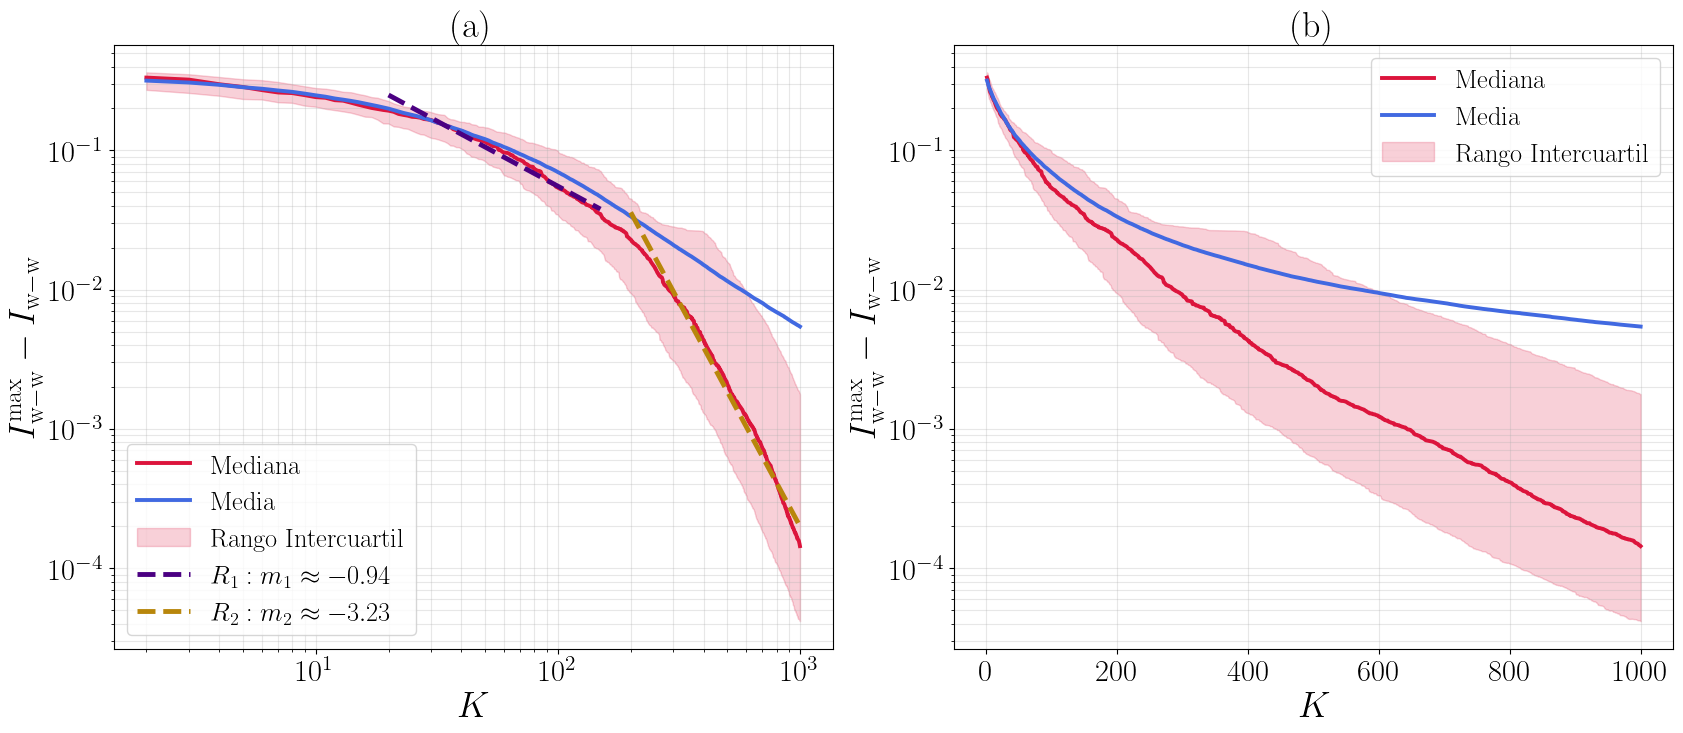

In [103]:
import os
import numpy as np
import matplotlib

# --- Tipografía clásica de LaTeX (Computer Modern) ---
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.serif'] = ['Computer Modern Roman']

carpeta_sim01 = "Simulacion_01"
ruta_sim01 = os.path.join(carpeta_sim01, "Sim01_20260804.npz")
Data_sim01 = np.load(ruta_sim01)

Out = Data_sim01['Out']
median = Data_sim01['median']
mean = Data_sim01['mean']
q1 = Data_sim01['q1']
q3 = Data_sim01['q3']
valor_fritz = (np.sqrt(2) - 1) / 16

it = np.arange(1, len(median) + 1)
K_valido = it[1:]

brecha_mediana = (valor_fritz - median)[1:]
brecha_media   = (valor_fritz - mean)[1:]
brecha_q1      = (valor_fritz - q1)[1:]
brecha_q3      = (valor_fritz - q3)[1:]

print("¿Q3 superó a Fritz en algún K?:", (brecha_q3 < 0).any())
print("¿Algún valor individual (Out) superó a Fritz?:", (Out > valor_fritz).any())

fig, axes = plt.subplots(1, 2, figsize=(17,7.5))

# --- Panel 1: log-log ---
ax = axes[0]
ax.loglog(K_valido, brecha_mediana, color='crimson', linewidth=2.8, label='Mediana')
ax.loglog(K_valido, brecha_media, color='royalblue', linewidth=2.8, label='Media')
ax.fill_between(K_valido, brecha_q3, brecha_q1, color='crimson', alpha=0.2, label='Rango Intercuartil')

for (k_min, k_max, color, etiqueta) in [(20, 150, '#4B0082', r'$R_1: m_1 \approx -0.94$'),
                                          (200, 1000, '#B8860B', r'$R_2: m_2 \approx -3.23$')]:
    mask = (K_valido >= k_min) & (K_valido <= k_max)
    pendiente, intercepto = np.polyfit(np.log(K_valido[mask]), np.log(brecha_mediana[mask]), 1)
    ajuste = np.exp(intercepto) * K_valido[mask]**pendiente
    ax.loglog(K_valido[mask], ajuste, color=color, linestyle='--', linewidth=3.5, label=etiqueta)

ax.set_xlabel(r"$K$", fontsize=26)
ax.set_ylabel(r"$I_{\rm w-w}^{\max} - I_{\rm w-w}$", fontsize=26)
ax.set_title("(a)", fontsize=26)
ax.legend(fontsize=19)
ax.grid(alpha=0.3, which='both')
ax.tick_params(labelsize=22)

# --- Panel 2: semilog-y ---
ax2 = axes[1]
ax2.semilogy(K_valido, brecha_mediana, color='crimson', linewidth=2.8, label='Mediana')
ax2.semilogy(K_valido, brecha_media, color='royalblue', linewidth=2.8, label='Media')
ax2.fill_between(K_valido, brecha_q3, brecha_q1, color='crimson', alpha=0.2, label='Rango Intercuartil')

ax2.set_xlabel(r"$K$", fontsize=26)
ax2.set_ylabel(r"$I_{\rm w-w}^{\max} - I_{\rm w-w}$", fontsize=26)
ax2.set_title("(b)", fontsize=26)
ax2.legend(fontsize=19)
ax2.grid(alpha=0.3, which='both')
ax2.tick_params(labelsize=22)

plt.tight_layout()
plt.savefig("Simulacion_01/Sim01_Max_Ent_conv.pdf")
plt.savefig("Simulacion_01/Sim01_Max_Ent_conv.png", dpi=600)
plt.show()

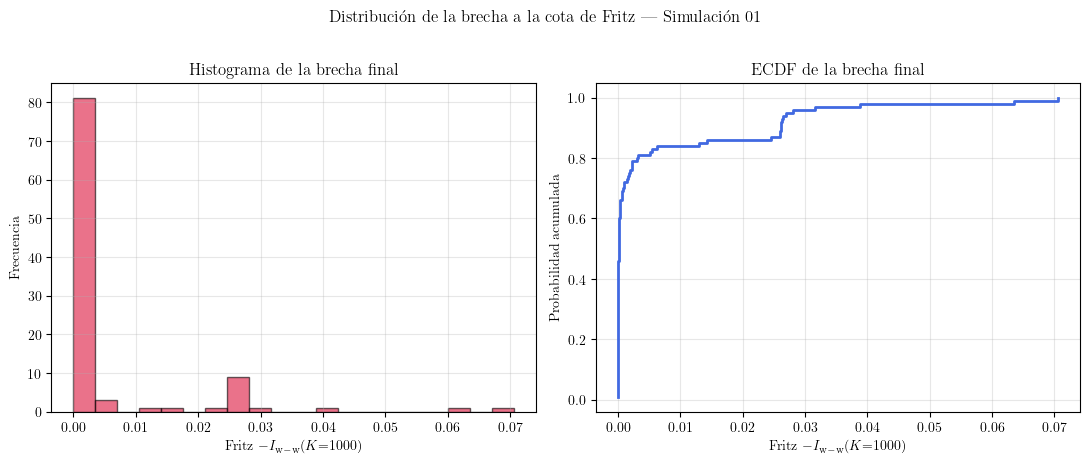

Brecha final — mediana: 0.000144, mínima: 0.000004, máxima: 0.070568


In [94]:
brecha_final = valor_fritz - Out[:, -1]   # brecha a la cota, última iteración, 100 realizaciones

fig, axes = plt.subplots(1, 2, figsize=(11,4.5))

# --- Histograma ---
axes[0].hist(brecha_final, bins=20, color='crimson', alpha=0.6, edgecolor='black')
axes[0].set_xlabel(r"Fritz $- I_{\rm w-w}(K{=}1000)$")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Histograma de la brecha final")
axes[0].grid(alpha=0.3)

# --- ECDF ---
valores_ordenados = np.sort(brecha_final)
prob_acumulada = np.arange(1, len(valores_ordenados)+1) / len(valores_ordenados)
axes[1].step(valores_ordenados, prob_acumulada, where='post', color='royalblue', linewidth=2)
axes[1].set_xlabel(r"Fritz $- I_{\rm w-w}(K{=}1000)$")
axes[1].set_ylabel("Probabilidad acumulada")
axes[1].set_title("ECDF de la brecha final")
axes[1].grid(alpha=0.3)

plt.suptitle("Distribución de la brecha a la cota de Fritz — Simulación 01", y=1.02)
plt.tight_layout()
plt.show()

print(f"Brecha final — mediana: {np.median(brecha_final):.6f}, mínima: {brecha_final.min():.6f}, máxima: {brecha_final.max():.6f}")

# Simulación 02

**Carpeta de datos:** `Simulacion_02`

**Parámetros:**

| Parámetro | Valor |
|---|---|
| Estado | Dos fuentes de Bell maximalmente entrelazadas ($\alpha,\beta$) + una fuente separable ($\gamma=|00\rangle$) |
| `max_rep` | 100 |
| `max_iter` | 1000 |
| `gains` | `[3, 0, 0.1, 0.602, 0.101]` |
| Optimizador | CSPSA (`minimize=False`, maximización) |

**Descripción:** a diferencia de Simulación 01 (tres fuentes maximalmente
entrelazadas), aquí solo dos fuentes ($\alpha,\beta$) son estados de Bell;
la tercera ($\gamma$) es separable. Sin parámetro variable, es una única
corrida de 100 repeticiones, comparable contra el valor óptimo de Fritz
para evaluar el efecto de reducir el entrelazamiento en una sola fuente.

**Archivos generados:** `Simulacion_02/Sim02_{fecha}.npz`

In [11]:
def construir_psi_fuentes(kets):
    """
    Construye el estado Psi de la red triangular a partir de los kets
    (4-vectores) de cada una de las tres fuentes: kets = [ket_alpha, ket_beta, ket_gamma].
    """
    Psi = triple_kron(kets[0], kets[1], kets[2])
    Psi = Psi.reshape(6*[2]).transpose([5,0,2,1,4,3]).flatten()
    return Psi


def construir_psi_dos_bell_una_separable():
    """
    Dos fuentes (alpha, beta) como estados de Bell maximalmente
    entrelazados; la tercera (gamma) como estado separable |00>.
    """
    ket_bell = np.array([0, 1, -1, 0]) / np.sqrt(2)
    ket_separable = np.array([1, 0, 0, 0])  # |00>, sin entrelazamiento
    return construir_psi_fuentes([ket_bell, ket_bell, ket_separable])


def _una_repeticion_sim02(gains, max_iter):
    """
    Una repetición de CSPSA: dos fuentes Bell maximalmente entrelazadas
    (alpha, beta) y una fuente separable (gamma).
    """
    Psi = construir_psi_dos_bell_una_separable()

    Us_in = np.array([ np.kron(random_unitary(2), random_unitary(2)) for _ in range(3) ])
    cspsa = CSPSA(gains=gains, minimize=False)

    results = cspsa.minimize(trineq, Us_in,
                                max_iter,
                                args = (Psi),
                                postprocessing=postprocessing )
    return results.fun


def ejecutar_simulacion_sim02(max_rep, max_iter, gains, sim_id, carpeta_sim,
                               fecha=None, n_jobs=-1):
    """
    Igual que ejecutar_simulacion_maxent, pero para el estado fijo de
    dos fuentes Bell maximalmente entrelazadas y una separable.
    """
    if fecha is None:
        fecha = datetime.now().strftime("%Y%m%d")

    os.makedirs(carpeta_sim, exist_ok=True)

    print(f"[{sim_id}] dos fuentes Bell max. entrelazadas, una separable "
          f"(paralelizando {max_rep} repeticiones, n_jobs={n_jobs})")

    resultados = Parallel(n_jobs=n_jobs)(
        delayed(_una_repeticion_sim02)(gains, max_iter) for _ in range(max_rep)
    )
    Out = np.array(resultados)

    nombre = f"{sim_id}_{fecha}.npz"
    ruta = os.path.join(carpeta_sim, nombre)

    np.savez(ruta,
             Out=Out,
             mean=Out.mean(axis=0),
             median=np.median(Out, axis=0),
             q1=np.percentile(Out, 25, axis=0),
             q3=np.percentile(Out, 75, axis=0),
             gains=gains, max_iter=max_iter,
             max_rep=max_rep, sim_id=sim_id, fecha=fecha)

    print(f"  Guardado: {ruta}")

In [ ]:
# ==========================================================
# Simulación 02 — Ejecución
# ==========================================================
max_rep_sim02 = 100
max_iter_sim02 = 1000
gains_sim02 = [3, 0, 0.1, 0.602, 0.101]
carpeta_sim02 = "Simulacion_02"
fecha_sim02 = datetime.now().strftime("%Y%m%d")

#ejecutar_simulacion_sim02(max_rep_sim02, max_iter_sim02,
#                           gains_sim02, "Sim02", carpeta_sim02, fecha_sim02)

[Sim02] dos fuentes Bell max. entrelazadas, una separable (paralelizando 100 repeticiones, n_jobs=-1)
  Guardado: Simulacion_02\Sim02_20260804.npz


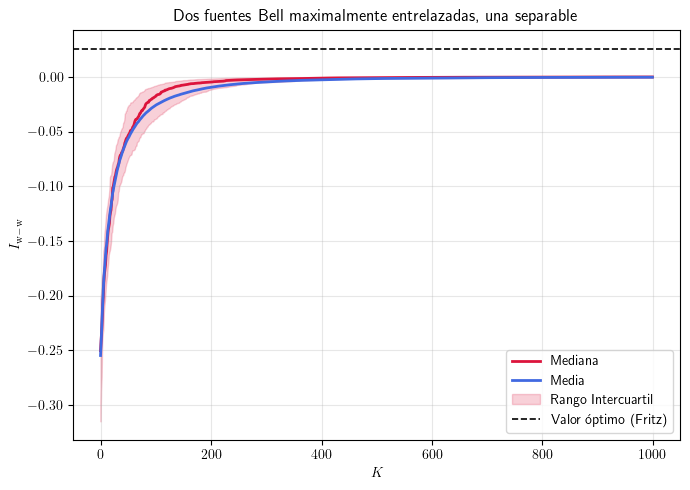

In [15]:
carpeta_sim02 = "Simulacion_02"
Data_sim02 = cargar_ultimo_npz_maxent(carpeta_sim02, "Sim02")

mean = Data_sim02['mean']
median = Data_sim02['median']
q1 = Data_sim02['q1']
q3 = Data_sim02['q3']
it = np.arange(len(median))

plt.figure(figsize=(7,5))

plt.plot(it, median, color='crimson', label='Mediana', linewidth=2)
plt.plot(it, mean, color='royalblue', label='Media', linewidth=2)
plt.fill_between(it, q1, q3, color='crimson', alpha=0.2, label='Rango Intercuartil')
plt.axhline(valor_fritz, color='black', linestyle='--', linewidth=1.2,
            label=r'Valor óptimo (Fritz)')

plt.xlabel(r"$K$")
plt.ylabel(r"$I_{\rm w-w}$")
plt.title(r"Dos fuentes Bell maximalmente entrelazadas, una separable")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("Simulacion_02/Sim02_Max_Ent.pdf")
plt.show()



C:\Users\jeanc\AppData\Local\Temp\ipykernel_127796\235487222.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


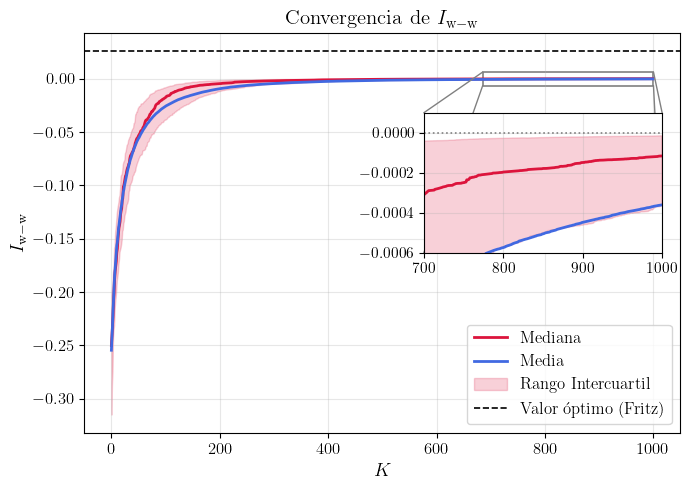

In [89]:
import os
import numpy as np
import matplotlib
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Rectangle, ConnectionPatch

# --- Tipografía clásica de LaTeX (Computer Modern) en todo el texto ---
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.serif'] = ['Computer Modern Roman']

carpeta_sim02 = "Simulacion_02"
ruta_sim02 = os.path.join(carpeta_sim02, "Sim02_20260804.npz")
Data_sim02 = np.load(ruta_sim02)

mean = Data_sim02['mean']
median = Data_sim02['median']
q1 = Data_sim02['q1']
q3 = Data_sim02['q3']
it = np.arange(len(median))

fig, ax = plt.subplots(figsize=(7,5))

# --- Gráfico principal ---
ax.plot(it, median, color='crimson', label='Mediana', linewidth=2)
ax.plot(it, mean, color='royalblue', label='Media', linewidth=2)
ax.fill_between(it, q1, q3, color='crimson', alpha=0.2, label='Rango Intercuartil')
ax.axhline(valor_fritz, color='black', linestyle='--', linewidth=1.2,
           label=r'Valor óptimo (Fritz)')

ax.set_xlabel(r"$K$", fontsize=14)
ax.set_ylabel(r"$I_{\rm w-w}$", fontsize=14)
ax.set_title(r"Convergencia de $I_{\rm w-w}$", fontsize=15)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
ax.tick_params(labelsize=12)

# --- Inset (zoom, K entre 700 y 1000), centrado en I_w-w = 0 ---
axins = inset_axes(ax, width="100%", height="100%",
                    bbox_to_anchor=(0.57, 0.45, 0.4, 0.35),
                    bbox_transform=ax.transAxes,
                    loc='lower left', borderpad=0)
axins.set_zorder(10)  # el inset queda por encima de las líneas inferiores

mask = it >= 700
axins.plot(it[mask], median[mask], color='crimson', linewidth=2)
axins.plot(it[mask], mean[mask], color='royalblue', linewidth=2)
axins.fill_between(it[mask], q1[mask], q3[mask], color='crimson', alpha=0.2)
axins.axhline(0, color='gray', linestyle=':', linewidth=1.2)

axins.set_ylim(-0.0006, 0.0001)
axins.set_xlim(700, 1000)
axins.tick_params(labelsize=11)
axins.grid(alpha=0.3)

# --- Rectángulo indicador ---
pad_x = 15
pad_y = 0.006

x0, x1 = 700 - pad_x, 1000
y0, y1 = -0.0006 - pad_y, 0.0001 + pad_y
ancho, alto = x1 - x0, y1 - y0

ax.add_patch(Rectangle((x0, y0), ancho, alto, fill=False, ec="0.5", lw=1.2))

# --- Líneas superiores (vértice sup. rectángulo -> vértice sup. inset) ---
con_izq_top = ConnectionPatch(xyA=(x0, y1), coordsA=ax.transData,
                               xyB=(0, 1), coordsB=axins.transAxes,
                               color="0.5", lw=1, zorder=5)
con_der_top = ConnectionPatch(xyA=(x1, y1), coordsA=ax.transData,
                               xyB=(1, 1), coordsB=axins.transAxes,
                               color="0.5", lw=1, zorder=5)

# --- Líneas inferiores (vértice inf. rectángulo -> vértice inf. inset),
#     quedan DETRÁS del inset gracias al zorder más bajo ---
con_izq_bot = ConnectionPatch(xyA=(x0, y0), coordsA=ax.transData,
                               xyB=(0, 0), coordsB=axins.transAxes,
                               color="0.5", lw=1, zorder=1)
con_der_bot = ConnectionPatch(xyA=(x1, y0), coordsA=ax.transData,
                               xyB=(1, 0), coordsB=axins.transAxes,
                               color="0.5", lw=1, zorder=1)

for con in [con_izq_top, con_der_top, con_izq_bot, con_der_bot]:
    fig.add_artist(con)

plt.tight_layout()
plt.savefig("Simulacion_02/Sim02_Max_Ent.pdf")
plt.savefig("Simulacion_02/Sim02_Max_Ent.png", dpi=600)
plt.show()

C:\Users\jeanc\AppData\Local\Temp\ipykernel_127796\180330102.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


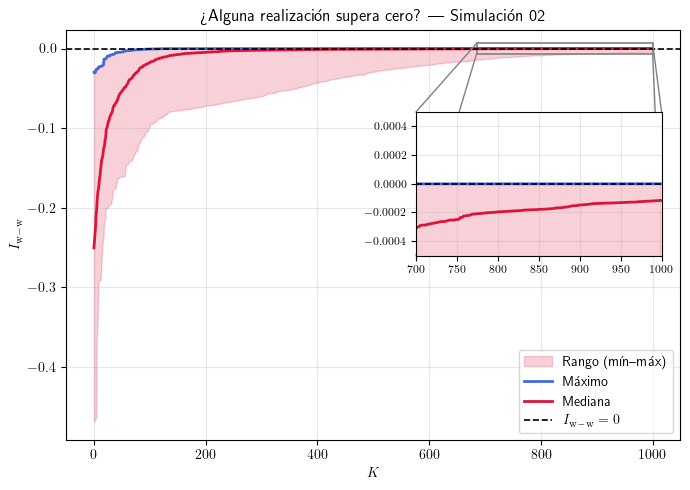

In [38]:
import glob
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Rectangle, ConnectionPatch

def cargar_ultimo_npz_maxent(carpeta, sim_id):
    patron = os.path.join(carpeta, f"{sim_id}_*.npz")
    archivos = sorted(glob.glob(patron))
    assert archivos, f"No se encontró ningún archivo para {sim_id} en {carpeta}"
    return np.load(archivos[-1])

Data_sim02 = cargar_ultimo_npz_maxent("Simulacion_02", "Sim02")

Out = Data_sim02['Out']
it = np.arange(Out.shape[1])

maximo = Out.max(axis=0)
minimo = Out.min(axis=0)
mediana = Data_sim02['median']

fig, ax = plt.subplots(figsize=(7,5))

# --- Gráfico principal (mismos colores que usamos antes) ---
ax.fill_between(it, minimo, maximo, color='crimson', alpha=0.2, label='Rango (mín–máx)')
ax.plot(it, maximo, color='royalblue', linewidth=2, label='Máximo')
ax.plot(it, mediana, color='crimson', linewidth=2, label='Mediana')
ax.axhline(0, color='black', linestyle='--', linewidth=1.2, label=r'$I_{\rm w-w}=0$')

cruces = maximo > 0
if cruces.any():
    ax.fill_between(it, 0, maximo, where=cruces, color='orange', alpha=0.4,
                     label='Alguna realización > 0')

ax.set_xlabel(r"$K$")
ax.set_ylabel(r"$I_{\rm w-w}$")
ax.set_title(r"¿Alguna realización supera cero? — Simulación 02")
ax.legend()
ax.grid(alpha=0.3)

# --- Inset (zoom, K entre 700 y 1000), mismo diseño que ya usamos ---
axins = inset_axes(ax, width="100%", height="100%",
                    bbox_to_anchor=(0.57, 0.45, 0.4, 0.35),
                    bbox_transform=ax.transAxes,
                    loc='lower left', borderpad=0)
axins.set_zorder(10)

mask = it >= 700
axins.fill_between(it[mask], minimo[mask], maximo[mask], color='crimson', alpha=0.2)
axins.plot(it[mask], maximo[mask], color='royalblue', linewidth=2)
axins.plot(it[mask], mediana[mask], color='crimson', linewidth=2)
axins.axhline(0, color='black', linestyle='--', linewidth=1.2)

axins.set_ylim(-0.0005, 0.0005)
axins.set_xlim(700, 1000)
axins.tick_params(labelsize=8)
axins.grid(alpha=0.3)

# --- Rectángulo indicador ---
pad_x = 15
pad_y = 0.006

x0, x1 = 700 - pad_x, 1000
y0, y1 = -0.0005 - pad_y, 0.0005 + pad_y
ancho, alto = x1 - x0, y1 - y0

ax.add_patch(Rectangle((x0, y0), ancho, alto, fill=False, ec="0.5", lw=1.2))

# --- Líneas superiores ---
con_izq_top = ConnectionPatch(xyA=(x0, y1), coordsA=ax.transData,
                               xyB=(0, 1), coordsB=axins.transAxes,
                               color="0.5", lw=1, zorder=5)
con_der_top = ConnectionPatch(xyA=(x1, y1), coordsA=ax.transData,
                               xyB=(1, 1), coordsB=axins.transAxes,
                               color="0.5", lw=1, zorder=5)

# --- Líneas inferiores (detrás del inset) ---
con_izq_bot = ConnectionPatch(xyA=(x0, y0), coordsA=ax.transData,
                               xyB=(0, 0), coordsB=axins.transAxes,
                               color="0.5", lw=1, zorder=1)
con_der_bot = ConnectionPatch(xyA=(x1, y0), coordsA=ax.transData,
                               xyB=(1, 0), coordsB=axins.transAxes,
                               color="0.5", lw=1, zorder=1)

for con in [con_izq_top, con_der_top, con_izq_bot, con_der_bot]:
    fig.add_artist(con)

plt.tight_layout()
plt.show()

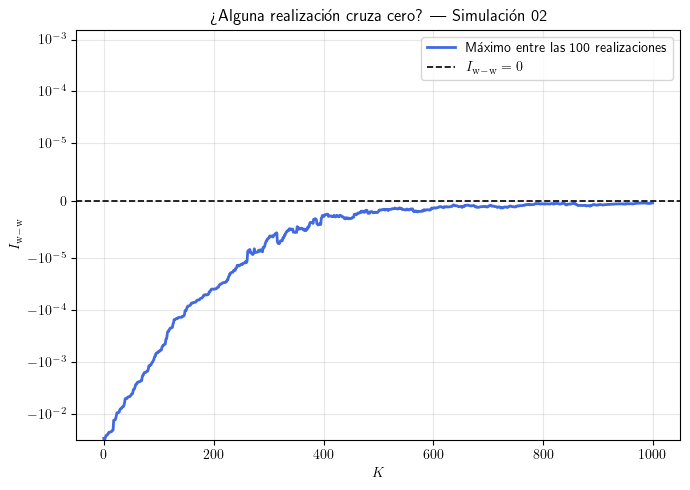

In [45]:
import glob

def cargar_ultimo_npz_maxent(carpeta, sim_id):
    patron = os.path.join(carpeta, f"{sim_id}_*.npz")
    archivos = sorted(glob.glob(patron))
    assert archivos, f"No se encontró ningún archivo para {sim_id} en {carpeta}"
    return np.load(archivos[-1])

Data_sim02 = cargar_ultimo_npz_maxent("Simulacion_02", "Sim02")

Out = Data_sim02['Out']
it = np.arange(Out.shape[1])
maximo = Out.max(axis=0)

plt.figure(figsize=(7,5))
plt.plot(it, maximo, color='royalblue', linewidth=2, label='Máximo entre las 100 realizaciones')
plt.axhline(0, color='black', linestyle='--', linewidth=1.2, label=r'$I_{\rm w-w}=0$')

plt.yscale('symlog', linthresh=1e-5)  # estira la zona cercana a cero
plt.xlabel(r"$K$")
plt.ylabel(r"$I_{\rm w-w}$")
plt.title(r"¿Alguna realización cruza cero? — Simulación 02")
plt.legend()
plt.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

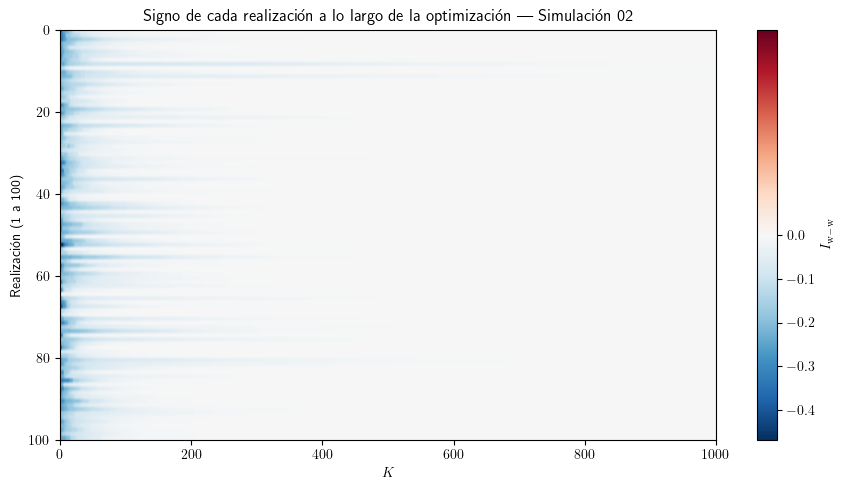

Píxeles positivos (realización, K) encontrados: 0


In [47]:
import glob
import matplotlib.colors as mcolors

def cargar_ultimo_npz_maxent(carpeta, sim_id):
    patron = os.path.join(carpeta, f"{sim_id}_*.npz")
    archivos = sorted(glob.glob(patron))
    assert archivos, f"No se encontró ningún archivo para {sim_id} en {carpeta}"
    return np.load(archivos[-1])

Data_sim02 = cargar_ultimo_npz_maxent("Simulacion_02", "Sim02")
Out = Data_sim02['Out']   # (100 realizaciones, 1000 iteraciones)

# Norma divergente centrada exactamente en 0
norm = mcolors.TwoSlopeNorm(vmin=Out.min(), vcenter=0, vmax=max(Out.max(), 1e-6))

plt.figure(figsize=(9,5))
im = plt.imshow(Out, aspect='auto', cmap='RdBu_r', norm=norm,
                 extent=[0, Out.shape[1], Out.shape[0], 0])

cbar = plt.colorbar(im)
cbar.set_label(r"$I_{\rm w-w}$")

plt.xlabel(r"$K$")
plt.ylabel("Realización (1 a 100)")
plt.title(r"Signo de cada realización a lo largo de la optimización — Simulación 02")
plt.tight_layout()
plt.show()

print("Píxeles positivos (realización, K) encontrados:", (Out > 0).sum())

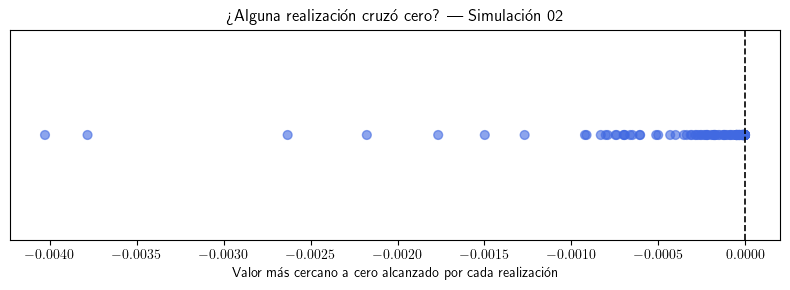

In [48]:
maximo_por_realizacion = Out.max(axis=1)   # el punto más cercano a cero de cada realización, sobre todo K

plt.figure(figsize=(8,3))
colores = ['crimson' if v > 0 else 'royalblue' for v in maximo_por_realizacion]
plt.scatter(maximo_por_realizacion, np.zeros_like(maximo_por_realizacion),
            c=colores, alpha=0.6, s=40)
plt.axvline(0, color='black', linestyle='--', linewidth=1.2)

plt.yticks([])
plt.xlabel(r"Valor más cercano a cero alcanzado por cada realización")
plt.title(r"¿Alguna realización cruzó cero? — Simulación 02")
plt.tight_layout()
plt.show()

C:\Users\jeanc\AppData\Local\Temp\ipykernel_127796\2240701512.py:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


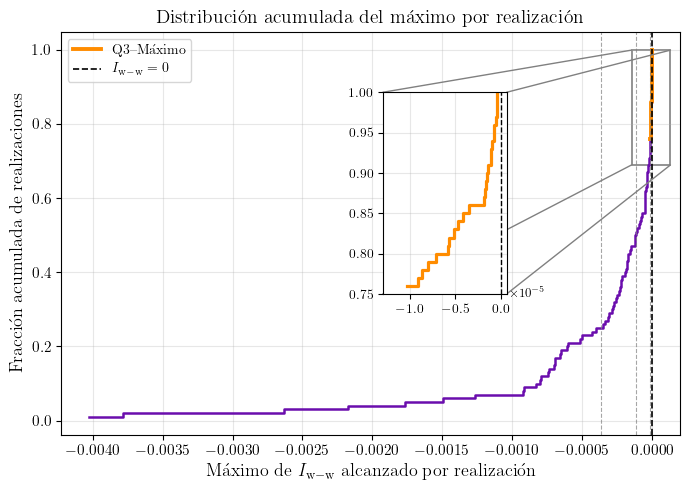

In [91]:
import glob
import matplotlib
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Rectangle, ConnectionPatch

# --- Tipografía clásica de LaTeX (Computer Modern) ---
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.serif'] = ['Computer Modern Roman']

def cargar_ultimo_npz_maxent(carpeta, sim_id):
    patron = os.path.join(carpeta, f"{sim_id}_*.npz")
    archivos = sorted(glob.glob(patron))
    assert archivos, f"No se encontró ningún archivo para {sim_id} en {carpeta}"
    return np.load(archivos[-1])

Data_sim02 = cargar_ultimo_npz_maxent("Simulacion_02", "Sim02")
Out = Data_sim02['Out']

maximo_por_realizacion = Out.max(axis=1)
valores_ordenados = np.sort(maximo_por_realizacion)
prob_acumulada = np.arange(1, len(valores_ordenados)+1) / len(valores_ordenados)

q1_val = np.percentile(maximo_por_realizacion, 25)
q2_val = np.percentile(maximo_por_realizacion, 50)
q3_val = np.percentile(maximo_por_realizacion, 75)
max_val = maximo_por_realizacion.max()

# --- Paleta: morado (curva base) / naranjo (tramo Q3-Máximo) ---
color_base = '#6A0DAD'
color_resaltado = '#FF8C00'

fig, ax = plt.subplots(figsize=(7,5))

# --- Curva completa ---
ax.step(valores_ordenados, prob_acumulada, where='post', color=color_base, linewidth=1.8)

# --- Tramo Q3 -> máximo, resaltado ---
mask_q3max = valores_ordenados >= q3_val
ax.step(valores_ordenados[mask_q3max], prob_acumulada[mask_q3max], where='post',
        color=color_resaltado, linewidth=2.8, label='Q3–Máximo')

# --- Líneas verticales tenues: Q1, Q2, Q3 ---
for q_val in [q1_val, q2_val, q3_val]:
    ax.axvline(q_val, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)

ax.axvline(0, color='black', linestyle='--', linewidth=1.2, label=r'$I_{\rm w-w}=0$')

ax.set_xlabel(r"Máximo de $I_{\rm w-w}$ alcanzado por realización", fontsize=13)
ax.set_ylabel("Fracción acumulada de realizaciones", fontsize=13)
ax.set_title("Distribución acumulada del máximo por realización", fontsize=14)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.tick_params(labelsize=11)

# --- Inset: zoom en el rectángulo Q3 -> Máximo ---
prob_en_q3 = np.searchsorted(valores_ordenados, q3_val, side='left') / len(valores_ordenados)

axins = inset_axes(ax, width="100%", height="100%",
                    bbox_to_anchor=(0.52, 0.35, 0.20, 0.5),
                    bbox_transform=ax.transAxes,
                    loc='lower left', borderpad=0)
axins.set_zorder(10)

axins.step(valores_ordenados[mask_q3max], prob_acumulada[mask_q3max], where='post',
           color=color_resaltado, linewidth=2.3)
axins.set_xlim(q3_val, max_val + 0.000001)
axins.set_ylim(prob_en_q3, 1.0)
axins.tick_params(labelsize=9.5)
axins.grid(alpha=0.3)

# --- Línea vertical punteada en 0, dentro del inset ---
axins.axvline(0, color='black', linestyle='--', linewidth=1)

# --- Ocultar el texto automático y ponerlo a la derecha del tick "0.0" ---
axins.xaxis.get_offset_text().set_visible(False)
axins.text(1.03, 0.035, r'$\times10^{-5}$', transform=axins.transAxes,
           fontsize=9, ha='left', va='top')

# --- Rectángulo indicador, llegando exactamente a y=1 (sin pasarse del eje) ---
pad_x = (ax.get_xlim()[1] - ax.get_xlim()[0]) * 0.03
pad_y = 0.06

x0, x1 = q3_val - pad_x, max_val + pad_x
y0, y1 = prob_en_q3 - pad_y, 1.0   # y1 fijo en 1.0, sin margen extra arriba

ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, ec="0.5", lw=1.2))

# --- Líneas superiores ---
con_izq_top = ConnectionPatch(xyA=(x0, y1), coordsA=ax.transData,
                               xyB=(0, 1), coordsB=axins.transAxes,
                               color="0.5", lw=1, zorder=5)
con_der_top = ConnectionPatch(xyA=(x1, y1), coordsA=ax.transData,
                               xyB=(1, 1), coordsB=axins.transAxes,
                               color="0.5", lw=1, zorder=5)

# --- Líneas inferiores (detrás del inset) ---
con_izq_bot = ConnectionPatch(xyA=(x0, y0), coordsA=ax.transData,
                               xyB=(0, 0), coordsB=axins.transAxes,
                               color="0.5", lw=1, zorder=1)
con_der_bot = ConnectionPatch(xyA=(x1, y0), coordsA=ax.transData,
                               xyB=(1, 0), coordsB=axins.transAxes,
                               color="0.5", lw=1, zorder=1)

for con in [con_izq_top, con_der_top, con_izq_bot, con_der_bot]:
    fig.add_artist(con)

plt.tight_layout()
plt.savefig("Simulacion_02/Sim02_Max_Ent_ECDF.pdf")
plt.savefig("Simulacion_02/Sim02_Max_Ent_ECDF.png", dpi=600)
plt.show()